# Imports

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict

# 1. A Propagator Model for trade


In [2]:
def open_convert_data(name : str) -> pd.DataFrame :
    df = pd.read_csv(f"Data/{name}", index_col="ts")
    df.index = pd.to_datetime(df.index)
    return df

In [3]:
df0_j0 = open_convert_data("stock0_day0_updates.csv.gz")
df0_j1 = open_convert_data("stock0_day1_updates.csv.gz")
df0_j2 = open_convert_data("stock0_day2_updates.csv.gz")

df1_j0 = open_convert_data("stock1_day0_updates.csv.gz")
df1_j1 = open_convert_data("stock1_day1_updates.csv.gz")
df1_j2 = open_convert_data("stock1_day2_updates.csv.gz")

df2_j0 = open_convert_data("stock2_day0_updates.csv.gz")
df2_j1 = open_convert_data("stock2_day1_updates.csv.gz")
df2_j2 = open_convert_data("stock2_day2_updates.csv.gz")

In [5]:
df0_j0.columns

Index(['type', 'bp', 'bq', 'ap', 'aq'], dtype='object')

In [4]:
datasets = {
    "stock0_day0": df0_j0,
    "stock0_day1": df0_j1,
    "stock0_day2": df0_j2,
    "stock1_day0": df1_j0,
    "stock1_day1": df1_j1,
    "stock1_day2": df1_j2,
    "stock2_day0": df2_j0,
    "stock2_day1": df2_j1,
    "stock2_day2": df2_j2,
}

## 1.1 Compute the response function for trades in trade time

In this section, we will follow the methodology and the formulas proposed in the following reference : Price response functions and spread impact in correlated financial markets from Henao-Londono & al.

It is well known that series of trades signs on a given stock are auto correlated. A classic explaination of this is that some brokers/traders split they orders to avoid impacting the balance of the LOB with large quantities and so the mid price. 

The following methodology rely heavily on section 3 of the paper so we tried ton implement the formulas given, using the same names. First of all they define the mid price (named mid-point) as followed : 

$m(t) = \frac{a(t) + b(t)}{2}$ 

In [ ]:
def compute_midpoint(df):
    df = df.copy()
    df["midpoint"] = (df["ap"] + df["bp"]) / 2
    return df

Following the methodology we need to compute the sign of the trade present in the dataset. To do so, we relied on the convention proposed in section 3.2 of the paper, eq (7). 

$\varepsilon ^{(t)}(t,n) = sgn(S(t,n) - S(t,n-1)) \space \text{  if  }\space S(t,n) \neq S(t,n-1)$

$\varepsilon ^{(t)}(t,n) = \varepsilon^{(t)}(t,n-1)$ otherwise

A $\varepsilon^{(t)} (t,n) = +1$ implies a trade triggered by a market order to buy, and $\varepsilon^{(t)} (t,n) = -1$ indicates a market order to sell. 

In [ ]:
def compute_trade_sign(df):
    df = df.copy()
    prices = df["ap"].values.astype(float)
    signs = np.zeros(len(df), dtype=int)

    for i in range(len(df)):
        if i == 0:
            signs[i] = 1  
        else:
            p_curr = prices[i]
            p_prev = prices[i - 1]

            if np.isnan(p_curr) or np.isnan(p_prev):
                signs[i] = signs[i - 1]
                continue

            diff = p_curr - p_prev
            if diff != 0:
                signs[i] = int(np.sign(diff))
            else:
                signs[i] = signs[i - 1]

    df["trade_sign"] = signs
    return df

We then process the dataset, dropping Nan Values for trades lines and adding the midprice and the sign of the trade. 

In [ ]:
def preprocess(df):
    df = df.copy()
    df = compute_midpoint(df)

    trades = df[df["type"] == "T"].copy()

    trades = trades.dropna(subset=["midpoint"])
    trades = trades.reset_index(drop=True)

    trades = compute_trade_sign(trades)
    return trades

We then compute log-returns, between to trade using the convention in the paper in equation (3). If $S(t)$ denotes the price of an asset at time $t$, we then use :

$r^{(l)}(t,\tau) = ln \frac{S(t+\tau)}{S(t)}$

With $\tau$ a lag. 

In [ ]:
def compute_return(midpoints, t, tau):
    t_tau = t + tau
    if t_tau >= len(midpoints) or t < 1:
        return np.nan
    m_t = midpoints[t - 1]       
    m_ttau = midpoints[t - 1 + tau]
    if m_t <= 0:
        return np.nan
    return np.log(m_ttau / m_t)

We define here the Response function. The response function measures price changes resulting from execution of market orders. The response function defined in previous work such as Bouchaud et al. use response function that only depend on the time lag $\tau$. We use a simplified response function based on trade time using the classical estimator for empirical mean : 

$R(\tau) = \frac{1}{N_{trades}} \sum_t [r(t-1,\tau) \times \varepsilon(t)]$

Where r is return and $\varepsilon$ the trade sign defined as above. 

In [ ]:
def self_response_trade_time(trades_df, tau):
    midpoints = trades_df["midpoint"].values
    signs = trades_df["trade_sign"].values
    N = len(trades_df)

    total = 0.0
    count = 0

    for t in range(1, N - tau):
        r = compute_return(midpoints, t, tau)
        if np.isnan(r):
            continue
        total += r * signs[t]
        count += 1

    return total / count if count > 0 else np.nan

Following what is proposed in the paper we implemented the cross response function to asses the impact of one stock on another in our dataset. The following formula define this cross response function : 

$R^{(t)}_{ij} (\tau) = \langle r_i^{(p)}(t-1,\tau)\varepsilon _j^{(t)}(t,n) \rangle _T$

In [ ]:
def cross_response_trade_time(trades_i, trades_j, tau):
    min_len = min(len(trades_i), len(trades_j))
    midpoints_i = trades_i["midpoint"].values[:min_len]
    signs_j = trades_j["trade_sign"].values[:min_len]

    total = 0.0
    count = 0

    for t in range(1, min_len - tau):
        r = compute_return(midpoints_i, t, tau)
        if np.isnan(r):
            continue
        total += r * signs_j[t]
        count += 1

    return total / count if count > 0 else np.nan

We aggregate and average the results for all days. 

In [ ]:
def aggregate_self_response(datasets, stock_id, tau_values):
    day_keys = [k for k in datasets if k.startswith(f"stock{stock_id}_")]
    results = {}

    for tau in tau_values:
        day_responses = []
        for key in day_keys:
            df = preprocess(datasets[key])
            r = self_response_trade_time(df, tau)
            if not np.isnan(r):
                day_responses.append(r)
        results[tau] = np.mean(day_responses) if day_responses else np.nan

    return results

In [ ]:
def aggregate_cross_response(datasets, stock_i, stock_j, tau_values):
    days = sorted(set(k.split("_")[1] for k in datasets)) 
    results = {}

    for tau in tau_values:
        day_responses = []
        for day in days:
            key_i = f"stock{stock_i}_{day}"
            key_j = f"stock{stock_j}_{day}"
            if key_i not in datasets or key_j not in datasets:
                continue
            df_i = preprocess(datasets[key_i])
            df_j = preprocess(datasets[key_j])
            r = cross_response_trade_time(df_i, df_j, tau)
            if not np.isnan(r):
                day_responses.append(r)
        results[tau] = np.mean(day_responses) if day_responses else np.nan

    return results

We finally plot the results : 

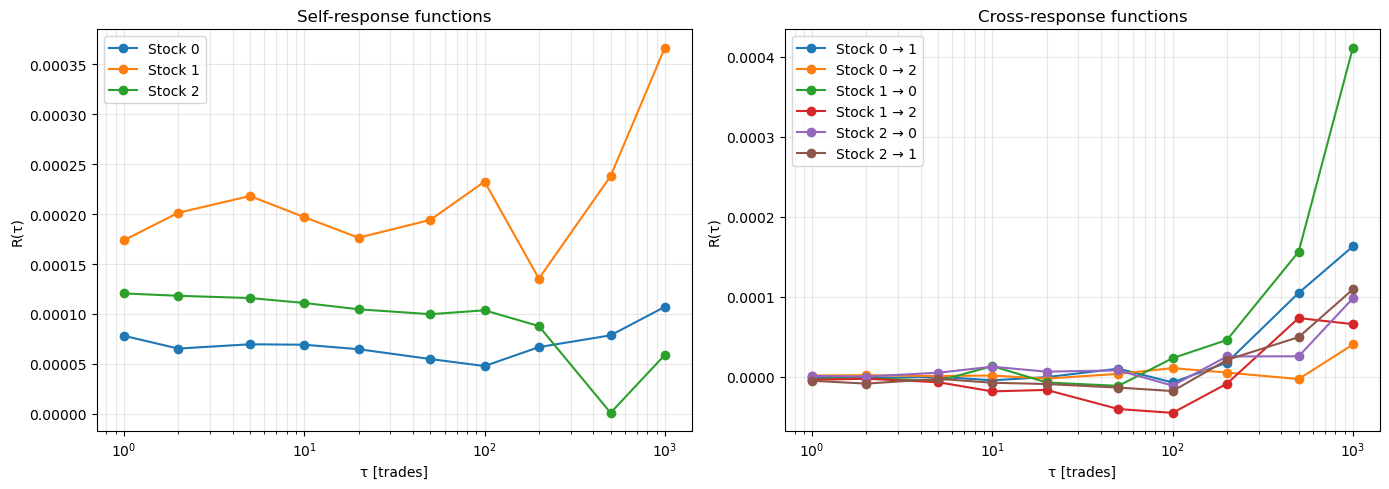

In [ ]:
tau_values = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

n_stocks = 3
self_responses = {}
for s in range(n_stocks):
    self_responses[s] = aggregate_self_response(datasets, stock_id=s, tau_values=tau_values)

cross_responses = {}
for i in range(n_stocks):
    for j in range(n_stocks):
        if i != j:
            cross_responses[(i, j)] = aggregate_cross_response(
                datasets, stock_i=i, stock_j=j, tau_values=tau_values
            )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for s in range(n_stocks):
    r = self_responses[s]
    ax.plot(list(r.keys()), list(r.values()), marker="o", label=f"Stock {s}")
ax.set_xscale("log")
ax.set_xlabel("τ [trades]")
ax.set_ylabel("R(τ)")
ax.set_title("Self-response functions")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

ax = axes[1]
for (i, j), r in cross_responses.items():
    ax.plot(list(r.keys()), list(r.values()), marker="o", label=f"Stock {i} → {j}")
ax.set_xscale("log")
ax.set_xlabel("τ [trades]")
ax.set_ylabel("R(τ)")
ax.set_title("Cross-response functions")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

We can observe here that in single stock setting, the reponse function is quite different for stock 1 than for stock 0 and 2. While the impact is bigger for stock 1, the function also tend to be an increasing function of the lag while for the other, the impact seems to be constant or even decreasing. 

For the cross term, we can see that on small lag, the response function seems to be close to 0, while with a big lag we observe bigger values. It seems quite logic since we expect the information of the price move on one stock to be price by another stock with a time propagation non zero as in a chock wave is a network of particle for example. 

## 1.2 Calibrate a propagator model for trades

## 1.3 Comment

# 2. A propagator model for LOB events